# Book recommendation system

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('updated_books.csv') 

In [3]:
df

,book_id,books_count,isbn,authors,original_publication_year,original_title,title,language_code,average_rating,ratings_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5
0,1,272,439023483,Suzanne Collins,2008.0,The Hunger Games,"The Hunger Games (The Hunger Games, #1)",eng,4.34,4780653,66715,127936,560092,1481305,2706317
1,2,491,439554934,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,Harry Potter and the Sorcerer's Stone (Harry P...,eng,4.44,4602479,75504,101676,455024,1156318,3011543
2,3,226,316015849,Stephenie Meyer,2005.0,Twilight,"Twilight (Twilight, #1)",en-US,3.57,3866839,456191,436802,793319,875073,1355439
3,4,487,61120081,Harper Lee,1960.0,To Kill a Mockingbird,To Kill a Mockingbird,eng,4.25,3198671,60427,117415,446835,1001952,1714267
4,5,1356,743273567,F. Scott Fitzgerald,1925.0,The Great Gatsby,The Great Gatsby,eng,3.89,2683664,86236,197621,606158,936012,947718
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,19,441019455,Ilona Andrews,2010.0,Bayou Moon,"Bayou Moon (The Edge, #2)",eng,4.09,17204,105,575,3538,7860,6778
9996,9997,19,067973371X,Robert A. Caro,1990.0,Means of Ascent,"Means of Ascent (The Years of Lyndon Johnson, #2)",eng,4.25,12582,303,551,1737,3389,6972
9997,9998,60,039330762X,Patrick O'Brian,1977.0,The Mauritius Command,The Mauritius Command,eng,4.35,9421,11,111,1191,4240,5180
9998,9999,7,61711527,Peggy Orenstein,2011.0,Cinderella Ate My Daughter: Dispatches from th...,Cinderella Ate My Daughter: Dispatches from th...,eng,3.65,11279,275,1002,3765,4577,2375


In [4]:
df.head()

,book_id,books_count,isbn,authors,original_publication_year,original_title,title,language_code,average_rating,ratings_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5
0,1,272,439023483,Suzanne Collins,2008.0,The Hunger Games,"The Hunger Games (The Hunger Games, #1)",eng,4.34,4780653,66715,127936,560092,1481305,2706317
1,2,491,439554934,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,Harry Potter and the Sorcerer's Stone (Harry P...,eng,4.44,4602479,75504,101676,455024,1156318,3011543
2,3,226,316015849,Stephenie Meyer,2005.0,Twilight,"Twilight (Twilight, #1)",en-US,3.57,3866839,456191,436802,793319,875073,1355439
3,4,487,61120081,Harper Lee,1960.0,To Kill a Mockingbird,To Kill a Mockingbird,eng,4.25,3198671,60427,117415,446835,1001952,1714267
4,5,1356,743273567,F. Scott Fitzgerald,1925.0,The Great Gatsby,The Great Gatsby,eng,3.89,2683664,86236,197621,606158,936012,947718


In [5]:
print(df.head())

   book_id  books_count       isbn                      authors  \
0        1          272  439023483              Suzanne Collins   
1        2          491  439554934  J.K. Rowling, Mary GrandPré   
2        3          226  316015849              Stephenie Meyer   
3        4          487   61120081                   Harper Lee   
4        5         1356  743273567          F. Scott Fitzgerald   

   original_publication_year                            original_title  \
0                     2008.0                          The Hunger Games   
1                     1997.0  Harry Potter and the Philosopher's Stone   
2                     2005.0                                  Twilight   
3                     1960.0                     To Kill a Mockingbird   
4                     1925.0                          The Great Gatsby   

                                               title language_code  \
0            The Hunger Games (The Hunger Games, #1)           eng   
1  Harry Pot

In [6]:
df.describe()

,book_id,books_count,original_publication_year,average_rating,ratings_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5
count,10000.00000,10000.000000,9979.000000,10000.000000,1.000000e+04,10000.000000,10000.000000,10000.000000,1.000000e+04,1.000000e+04
mean,5000.50000,75.712700,1981.987674,4.002191,5.400124e+04,1345.040600,3110.885000,11475.893800,1.996570e+04,2.378981e+04
std,2886.89568,170.470728,152.576665,0.254427,1.573700e+05,6635.626263,9717.123578,28546.449183,5.144736e+04,7.976889e+04
min,1.00000,1.000000,-1750.000000,2.470000,2.716000e+03,11.000000,30.000000,323.000000,7.500000e+02,7.540000e+02
25%,2500.75000,23.000000,1990.000000,3.850000,1.356875e+04,196.000000,656.000000,3112.000000,5.405750e+03,5.334000e+03
50%,5000.50000,40.000000,2004.000000,4.020000,2.115550e+04,391.000000,1163.000000,4894.000000,8.269500e+03,8.836000e+03
75%,7500.25000,67.000000,2011.000000,4.180000,4.105350e+04,885.000000,2353.250000,9287.000000,1.602350e+04,1.730450e+04
max,10000.00000,3455.000000,2017.000000,4.820000,4.780653e+06,456191.000000,436802.000000,793319.000000,1.481305e+06,3.011543e+06


In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   book_id                    10000 non-null  int64  
 1   books_count                10000 non-null  int64  
 2   isbn                       9300 non-null   object 
 3   authors                    10000 non-null  object 
 4   original_publication_year  9979 non-null   float64
 5   original_title             9415 non-null   object 
 6   title                      10000 non-null  object 
 7   language_code              8916 non-null   object 
 8   average_rating             10000 non-null  float64
 9   ratings_count              10000 non-null  int64  
 10  ratings_1                  10000 non-null  int64  
 11  ratings_2                  10000 non-null  int64  
 12  ratings_3                  10000 non-null  int64  
 13  ratings_4                  10000 non-null  int6

In [8]:
df.isnull().sum()

book_id                         0
books_count                     0
isbn                          700
authors                         0
original_publication_year      21
original_title                585
title                           0
language_code                1084
average_rating                  0
ratings_count                   0
ratings_1                       0
ratings_2                       0
ratings_3                       0
ratings_4                       0
ratings_5                       0
dtype: int64

In [9]:
# Fill missing ISBN 
df['isbn'] = df['isbn'].fillna('NA')

In [10]:
df['original_publication_year'] = df['original_publication_year'].fillna(df['original_publication_year'].median())

In [11]:
df['original_title'] = df['original_title'].fillna('Unknown')

In [12]:
most_common_language = df['language_code'].mode()[0]
df['language_code'] = df['language_code'].fillna(most_common_language)

In [13]:
df.isnull().sum()

book_id                      0
books_count                  0
isbn                         0
authors                      0
original_publication_year    0
original_title               0
title                        0
language_code                0
average_rating               0
ratings_count                0
ratings_1                    0
ratings_2                    0
ratings_3                    0
ratings_4                    0
ratings_5                    0
dtype: int64

In [14]:
df = df.drop_duplicates()

In [15]:
df['total_ratings'] = df['ratings_1'] + df['ratings_2'] + df['ratings_3'] + df['ratings_4'] + df['ratings_5']

In [16]:
df['average_rating'] = df['total_ratings'] / df['ratings_count']

In [17]:
df.head()

,book_id,books_count,isbn,authors,original_publication_year,original_title,title,language_code,average_rating,ratings_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,total_ratings
0,1,272,439023483,Suzanne Collins,2008.0,The Hunger Games,"The Hunger Games (The Hunger Games, #1)",eng,1.033826,4780653,66715,127936,560092,1481305,2706317,4942365
1,2,491,439554934,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,Harry Potter and the Sorcerer's Stone (Harry P...,eng,1.042930,4602479,75504,101676,455024,1156318,3011543,4800065
2,3,226,316015849,Stephenie Meyer,2005.0,Twilight,"Twilight (Twilight, #1)",en-US,1.012927,3866839,456191,436802,793319,875073,1355439,3916824
3,4,487,61120081,Harper Lee,1960.0,To Kill a Mockingbird,To Kill a Mockingbird,eng,1.044464,3198671,60427,117415,446835,1001952,1714267,3340896
4,5,1356,743273567,F. Scott Fitzgerald,1925.0,The Great Gatsby,The Great Gatsby,eng,1.033566,2683664,86236,197621,606158,936012,947718,2773745


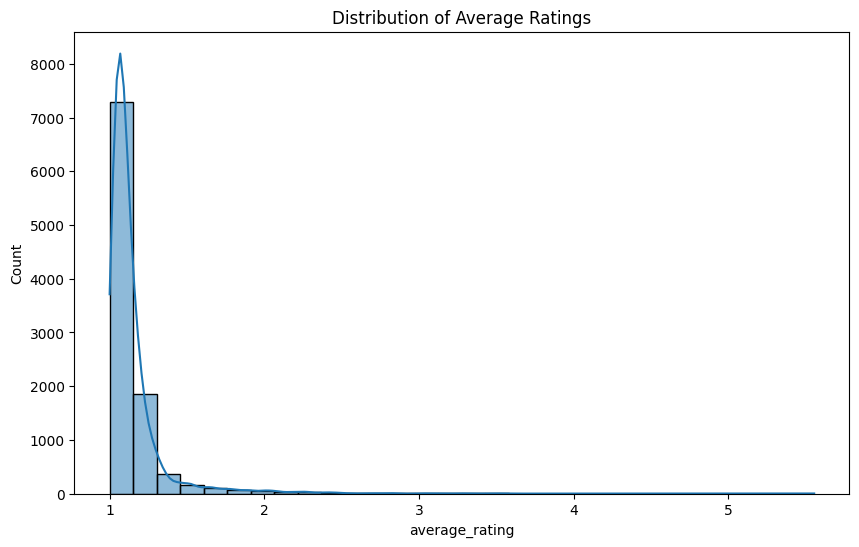

In [19]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='average_rating', bins=30, kde=True)
plt.title('Distribution of Average Ratings')
plt.show()

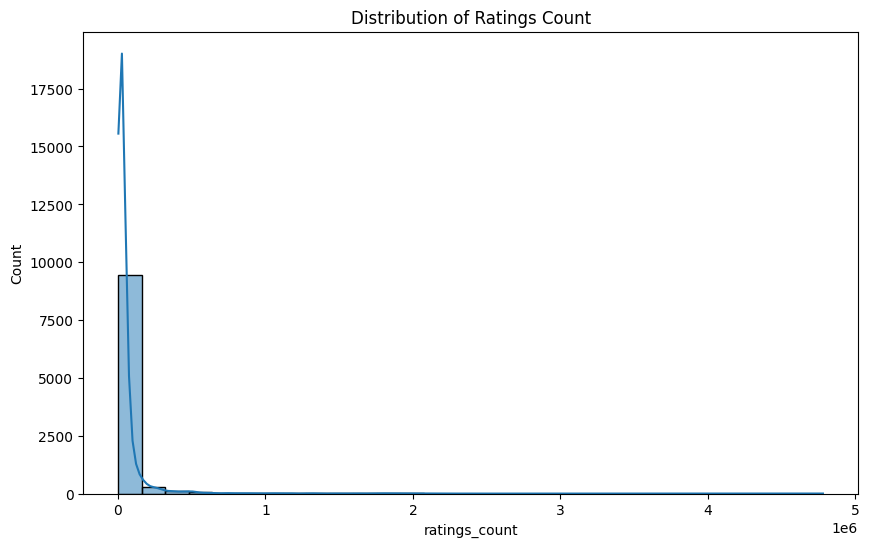

In [20]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='ratings_count', bins=30, kde=True)
plt.title('Distribution of Ratings Count')
plt.show()

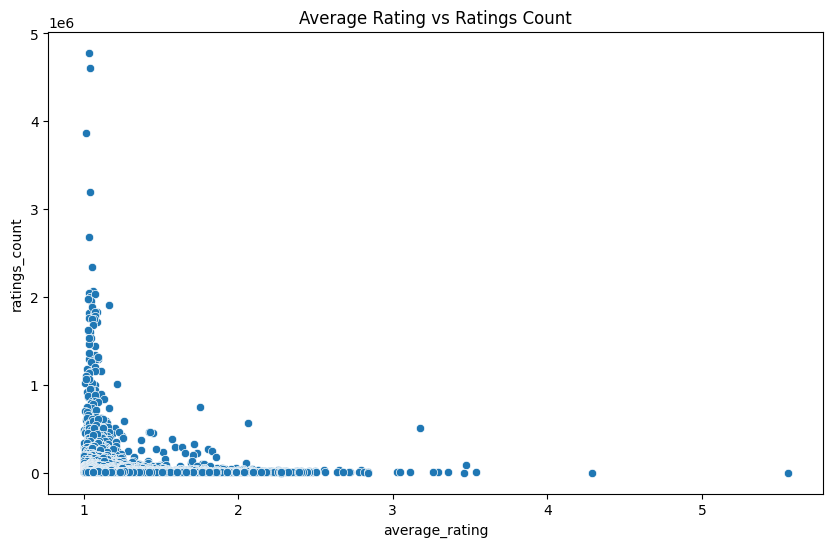

In [21]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='average_rating', y='ratings_count')
plt.title('Average Rating vs Ratings Count')
plt.show()

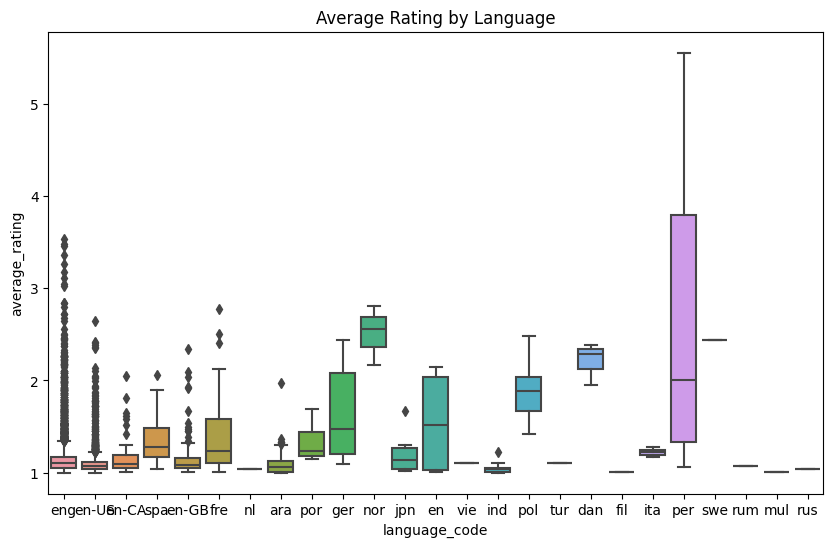

In [22]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='language_code', y='average_rating')
plt.title('Average Rating by Language')
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_4272\1531176317.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_matrix = df.corr()


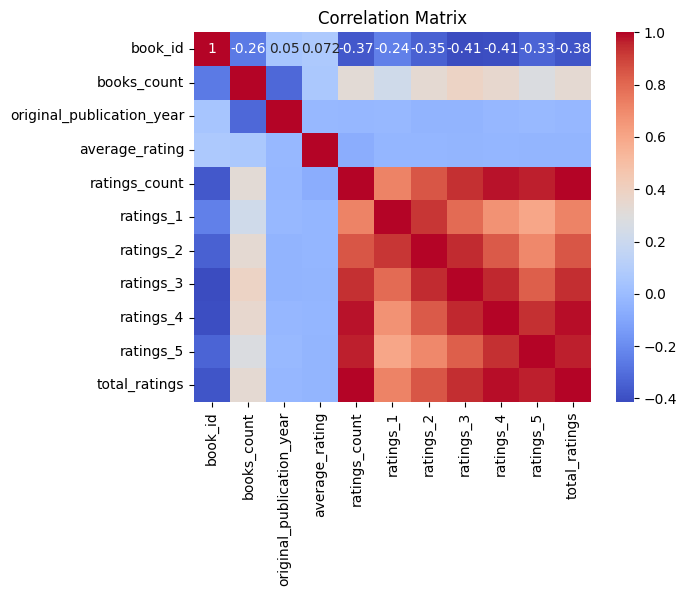

In [23]:
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

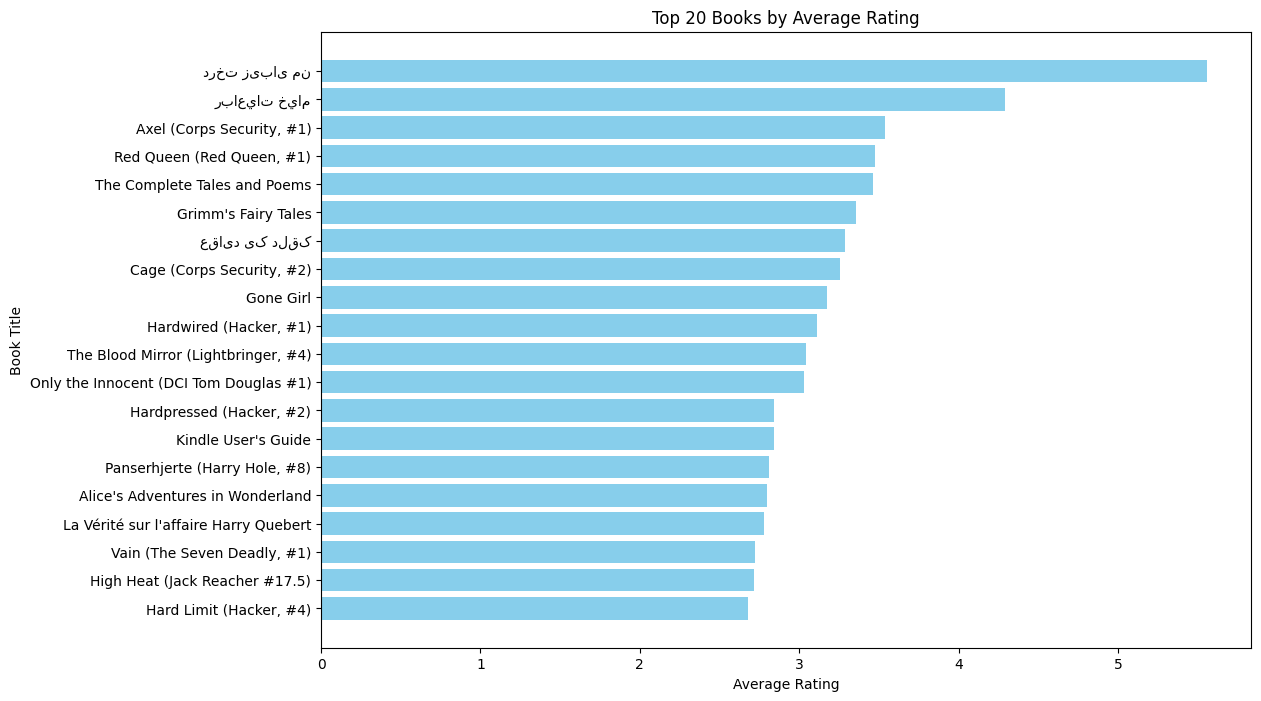

In [24]:
top_books = df.nlargest(20, 'average_rating')

# Plotting
plt.figure(figsize=(12, 8))
plt.barh(top_books['title'], top_books['average_rating'], color='skyblue')
plt.xlabel('Average Rating')
plt.ylabel('Book Title')
plt.title('Top 20 Books by Average Rating')
plt.gca().invert_yaxis()  # Invert y-axis to show the highest rating at the top
plt.show()

In [25]:
df.shape

(10000, 16)

In [26]:
from scipy import stats
features = ['books_count', 'original_publication_year', 'average_rating', 'ratings_count', 'total_ratings' , 'average_rating']
for feature in features:
    # Calculate IQR
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1

    # Determine Outlier Thresholds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Impute Outliers
    df[feature] = np.where((df[feature] < lower_bound) | (df[feature] > upper_bound), df[feature].median(), df[feature])

In [27]:
df

,book_id,books_count,isbn,authors,original_publication_year,original_title,title,language_code,average_rating,ratings_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,total_ratings
0,1,40.0,439023483,Suzanne Collins,2008.0,The Hunger Games,"The Hunger Games (The Hunger Games, #1)",eng,1.033826,21155.5,66715,127936,560092,1481305,2706317,23832.5
1,2,40.0,439554934,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,Harry Potter and the Sorcerer's Stone (Harry P...,eng,1.042930,21155.5,75504,101676,455024,1156318,3011543,23832.5
2,3,40.0,316015849,Stephenie Meyer,2005.0,Twilight,"Twilight (Twilight, #1)",en-US,1.012927,21155.5,456191,436802,793319,875073,1355439,23832.5
3,4,40.0,61120081,Harper Lee,1960.0,To Kill a Mockingbird,To Kill a Mockingbird,eng,1.044464,21155.5,60427,117415,446835,1001952,1714267,23832.5
4,5,40.0,743273567,F. Scott Fitzgerald,2004.0,The Great Gatsby,The Great Gatsby,eng,1.033566,21155.5,86236,197621,606158,936012,947718,23832.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,19.0,441019455,Ilona Andrews,2010.0,Bayou Moon,"Bayou Moon (The Edge, #2)",eng,1.096024,17204.0,105,575,3538,7860,6778,18856.0
9996,9997,19.0,067973371X,Robert A. Caro,1990.0,Means of Ascent,"Means of Ascent (The Years of Lyndon Johnson, #2)",eng,1.029407,12582.0,303,551,1737,3389,6972,12952.0
9997,9998,60.0,039330762X,Patrick O'Brian,1977.0,The Mauritius Command,The Mauritius Command,eng,1.139263,9421.0,11,111,1191,4240,5180,10733.0
9998,9999,7.0,61711527,Peggy Orenstein,2011.0,Cinderella Ate My Daughter: Dispatches from th...,Cinderella Ate My Daughter: Dispatches from th...,eng,1.063392,11279.0,275,1002,3765,4577,2375,11994.0


In [28]:
from gensim.models import Word2Vec

# Split the authors on comma (assuming multiple authors are separated by comma)
df['authors_split'] = df['authors'].apply(lambda x: x.split(','))

# Train a Word2Vec model
model = Word2Vec(df['authors_split'], min_count=1)

# Create a dictionary with authors as keys and their corresponding vectors as values
author_vec = {author: model.wv[author] for author in model.wv.index_to_key}

# Create a new feature with the average vector of all authors of each book
df['authors_vec'] = df['authors_split'].apply(lambda x: np.mean([author_vec[author] for author in x], axis=0))

In [29]:
df

,book_id,books_count,isbn,authors,original_publication_year,original_title,title,language_code,average_rating,ratings_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,total_ratings,authors_split,authors_vec
0,1,40.0,439023483,Suzanne Collins,2008.0,The Hunger Games,"The Hunger Games (The Hunger Games, #1)",eng,1.033826,21155.5,66715,127936,560092,1481305,2706317,23832.5,[Suzanne Collins],"[0.006086413, -0.00059236167, 0.002309693, -0...."
1,2,40.0,439554934,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,Harry Potter and the Sorcerer's Stone (Harry P...,eng,1.042930,21155.5,75504,101676,455024,1156318,3011543,23832.5,"[J.K. Rowling, Mary GrandPré]","[0.0006743567, 0.005012413, -0.004515261, 0.00..."
2,3,40.0,316015849,Stephenie Meyer,2005.0,Twilight,"Twilight (Twilight, #1)",en-US,1.012927,21155.5,456191,436802,793319,875073,1355439,23832.5,[Stephenie Meyer],"[0.005264245, -0.009025896, 0.007085943, -0.00..."
3,4,40.0,61120081,Harper Lee,1960.0,To Kill a Mockingbird,To Kill a Mockingbird,eng,1.044464,21155.5,60427,117415,446835,1001952,1714267,23832.5,[Harper Lee],"[-0.007755573, 0.004908173, -0.000392344, -0.0..."
4,5,40.0,743273567,F. Scott Fitzgerald,2004.0,The Great Gatsby,The Great Gatsby,eng,1.033566,21155.5,86236,197621,606158,936012,947718,23832.5,[F. Scott Fitzgerald],"[-0.006708578, 0.0011282607, -0.0087105045, -0..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,19.0,441019455,Ilona Andrews,2010.0,Bayou Moon,"Bayou Moon (The Edge, #2)",eng,1.096024,17204.0,105,575,3538,7860,6778,18856.0,[Ilona Andrews],"[0.00603099, -0.0055984342, 0.007892033, 0.006..."
9996,9997,19.0,067973371X,Robert A. Caro,1990.0,Means of Ascent,"Means of Ascent (The Years of Lyndon Johnson, #2)",eng,1.029407,12582.0,303,551,1737,3389,6972,12952.0,[Robert A. Caro],"[-0.0057621324, -0.0029711819, 0.006409072, 0...."
9997,9998,60.0,039330762X,Patrick O'Brian,1977.0,The Mauritius Command,The Mauritius Command,eng,1.139263,9421.0,11,111,1191,4240,5180,10733.0,[Patrick O'Brian],"[-0.0010628438, -0.002514535, 0.0005216014, -0..."
9998,9999,7.0,61711527,Peggy Orenstein,2011.0,Cinderella Ate My Daughter: Dispatches from th...,Cinderella Ate My Daughter: Dispatches from th...,eng,1.063392,11279.0,275,1002,3765,4577,2375,11994.0,[Peggy Orenstein],"[-0.0037250102, 0.0038013672, -0.00085758924, ..."


In [30]:
df = pd.get_dummies(df, columns=['language_code'])

In [31]:
df

,book_id,books_count,isbn,authors,original_publication_year,original_title,title,average_rating,ratings_count,ratings_1,...,language_code_nor,language_code_per,language_code_pol,language_code_por,language_code_rum,language_code_rus,language_code_spa,language_code_swe,language_code_tur,language_code_vie
0,1,40.0,439023483,Suzanne Collins,2008.0,The Hunger Games,"The Hunger Games (The Hunger Games, #1)",1.033826,21155.5,66715,...,0,0,0,0,0,0,0,0,0,0
1,2,40.0,439554934,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,Harry Potter and the Sorcerer's Stone (Harry P...,1.042930,21155.5,75504,...,0,0,0,0,0,0,0,0,0,0
2,3,40.0,316015849,Stephenie Meyer,2005.0,Twilight,"Twilight (Twilight, #1)",1.012927,21155.5,456191,...,0,0,0,0,0,0,0,0,0,0
3,4,40.0,61120081,Harper Lee,1960.0,To Kill a Mockingbird,To Kill a Mockingbird,1.044464,21155.5,60427,...,0,0,0,0,0,0,0,0,0,0
4,5,40.0,743273567,F. Scott Fitzgerald,2004.0,The Great Gatsby,The Great Gatsby,1.033566,21155.5,86236,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,19.0,441019455,Ilona Andrews,2010.0,Bayou Moon,"Bayou Moon (The Edge, #2)",1.096024,17204.0,105,...,0,0,0,0,0,0,0,0,0,0
9996,9997,19.0,067973371X,Robert A. Caro,1990.0,Means of Ascent,"Means of Ascent (The Years of Lyndon Johnson, #2)",1.029407,12582.0,303,...,0,0,0,0,0,0,0,0,0,0
9997,9998,60.0,039330762X,Patrick O'Brian,1977.0,The Mauritius Command,The Mauritius Command,1.139263,9421.0,11,...,0,0,0,0,0,0,0,0,0,0
9998,9999,7.0,61711527,Peggy Orenstein,2011.0,Cinderella Ate My Daughter: Dispatches from th...,Cinderella Ate My Daughter: Dispatches from th...,1.063392,11279.0,275,...,0,0,0,0,0,0,0,0,0,0
